<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Classification-based Rating Mode Prediction using Embedding Features**


## **Introduction**
In the lab 6.3.4, we built regression models to predict numerical course ratings using the embedding feature vectors extracted from neural networks. We can also consider the prediction problem as a classification problem also using embedding features.


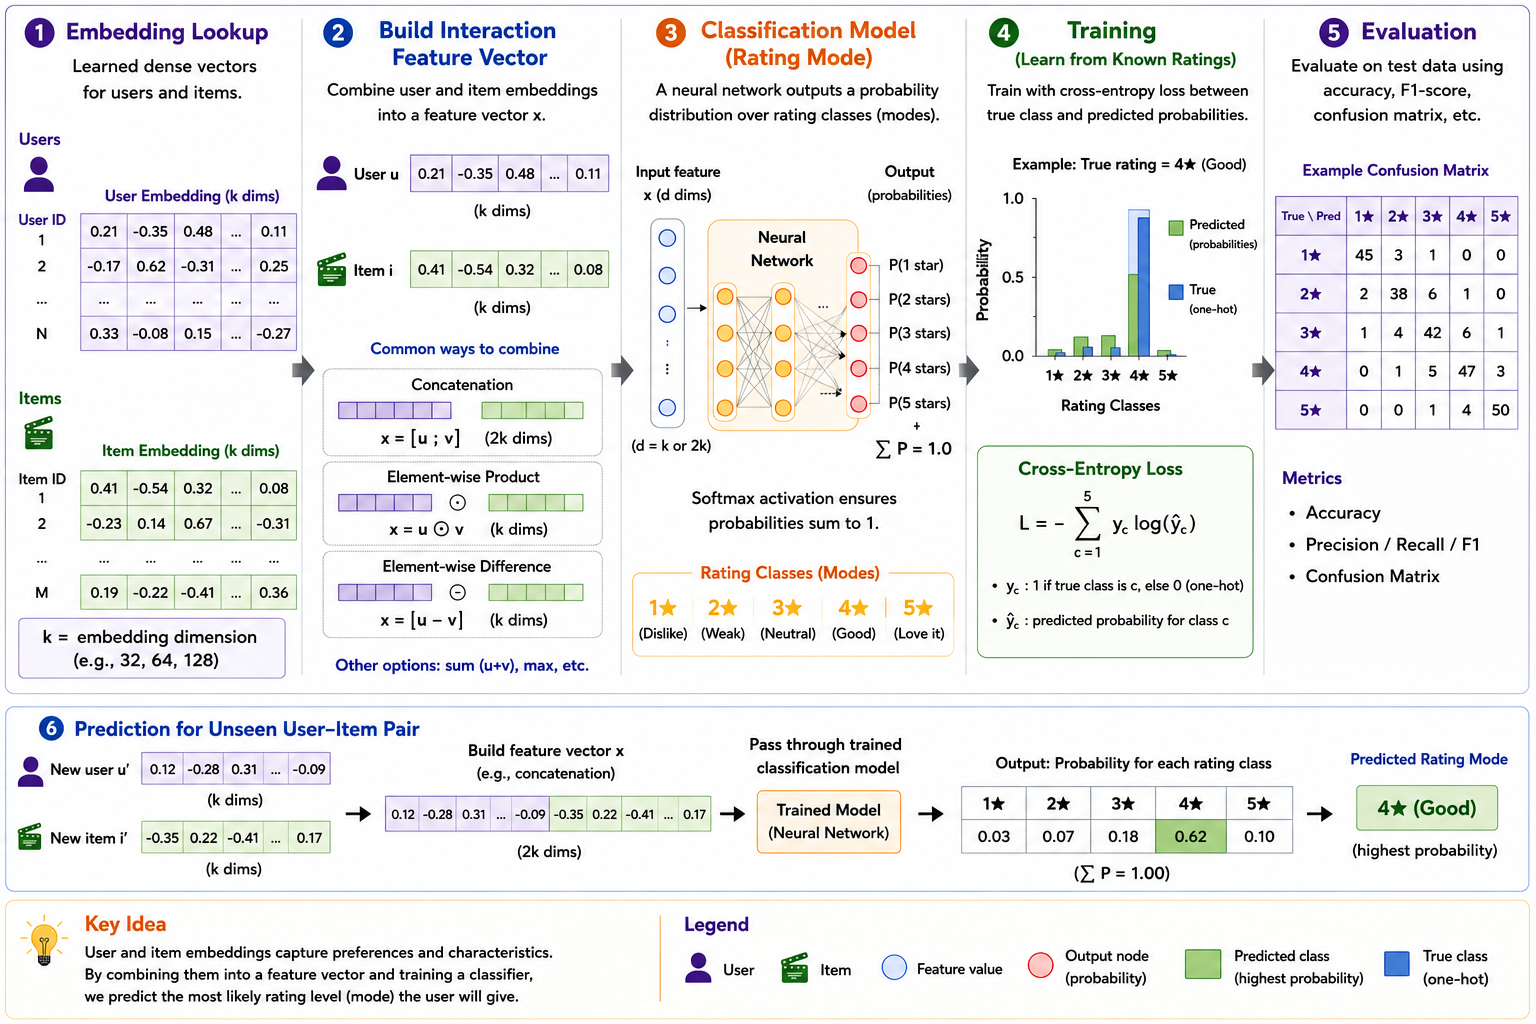

For the workflow, we first extract two embedding matrices out of the neural network, and aggregate them to be a single interaction feature vector as input data `X`.

This time, with the interaction label `Y` as categorical rating mode, we can build classification models to approximate the mapping from `X` to `Y`, as shown in the above flowchart.


## **Objectives**


* Build classification models to predict rating modes using the combined embedding vectors


----


### **Prepare and setup lab environment**


First install and import required libraries:


In [299]:
#%pip install scikit-learn
#%pip install pandas

In [300]:
# also set a random state
rs = 123

In [301]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


### **Load embedding datasets**


In [302]:
#rating_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"
rating_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/ratings.csv"

user_emb_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_embeddings.csv"
item_emb_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_embeddings.csv"



The first dataset is the rating dataset contains user-item interaction matrix


In [303]:
rating_df = pd.read_csv(rating_url)

In [304]:
rating_df.head()

,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0
3,380098,BD0211EN,3.0
4,779563,DS0101EN,3.0


As you can see from the above data, the user and item are just ids, let's substitute them with their embedding vectors


In [305]:
user_emb = pd.read_csv(user_emb_url)
item_emb = pd.read_csv(item_emb_url)

In [306]:
user_emb.head()

,user,UFeature0,UFeature1,UFeature2,UFeature3,UFeature4,UFeature5,UFeature6,UFeature7,UFeature8,UFeature9,UFeature10,UFeature11,UFeature12,UFeature13,UFeature14,UFeature15
0,1889878,0.080721,-0.129561,0.087998,0.030231,0.082691,-0.004176,-0.003480,0.091464,-0.040247,0.018958,-0.153328,-0.090143,0.082830,-0.058721,0.057929,-0.001472
1,1342067,0.068047,-0.112781,0.045208,-0.007570,-0.038382,0.068037,0.114949,0.104128,-0.034401,0.004011,0.064832,0.165857,-0.004384,0.053257,0.014308,0.056684
2,1990814,0.124623,0.012910,-0.072627,0.049935,0.020158,0.133306,-0.035366,-0.156026,0.039269,0.042195,0.014695,-0.115989,0.031158,0.102021,-0.020601,0.116488
3,380098,-0.034870,0.000715,0.077406,0.070311,-0.043007,-0.035446,0.032846,-0.060944,0.112384,0.002114,0.090660,-0.068545,0.008967,0.063962,0.052347,0.018072
4,779563,0.106414,-0.001887,-0.017211,-0.042277,-0.074953,-0.056732,0.074610,-0.019367,-0.031341,0.064896,-0.048158,-0.047309,-0.007544,0.010474,-0.032287,-0.083983


In [307]:
item_emb.head()

,item,CFeature0,CFeature1,CFeature2,CFeature3,CFeature4,CFeature5,CFeature6,CFeature7,CFeature8,CFeature9,CFeature10,CFeature11,CFeature12,CFeature13,CFeature14,CFeature15
0,CC0101EN,0.009657,-0.005238,-0.004098,0.016303,-0.005274,-0.000361,-0.015081,-0.012229,0.015686,0.008401,-0.035495,0.009381,-0.032560,-0.007292,0.000966,-0.006218
1,CL0101EN,-0.008611,0.028041,0.021899,-0.001465,0.006900,-0.017981,0.010899,-0.037610,-0.019397,-0.025682,-0.000620,0.038803,0.000196,-0.045343,0.012863,0.019429
2,ML0120ENv3,0.027439,-0.027649,-0.007484,-0.059451,0.003972,0.020496,-0.012695,0.036138,0.019965,0.018686,-0.010450,-0.050011,0.013845,-0.044454,-0.001480,-0.007559
3,BD0211EN,0.020163,-0.011972,-0.003714,-0.015548,-0.007540,0.014847,-0.005700,-0.006068,-0.005792,-0.023036,0.015999,-0.023480,0.015469,0.022221,-0.023115,-0.001785
4,DS0101EN,0.006399,0.000492,0.005640,0.009639,-0.005487,-0.000590,-0.010015,-0.001514,-0.017598,0.003590,0.016799,0.002732,0.005162,0.015031,-0.000877,-0.021283


In [308]:
# Merge user embedding features
merged_df = pd.merge(rating_df, user_emb, how='left', left_on='user', right_on='user').fillna(0)
# Merge course embedding features
merged_df = pd.merge(merged_df, item_emb, how='left', left_on='item', right_on='item').fillna(0)

In [309]:
merged_df.head()

,user,item,rating,UFeature0,UFeature1,UFeature2,UFeature3,UFeature4,UFeature5,UFeature6,...,CFeature6,CFeature7,CFeature8,CFeature9,CFeature10,CFeature11,CFeature12,CFeature13,CFeature14,CFeature15
0,1889878,CC0101EN,3.0,0.080721,-0.129561,0.087998,0.030231,0.082691,-0.004176,-0.003480,...,-0.015081,-0.012229,0.015686,0.008401,-0.035495,0.009381,-0.032560,-0.007292,0.000966,-0.006218
1,1342067,CL0101EN,3.0,0.068047,-0.112781,0.045208,-0.007570,-0.038382,0.068037,0.114949,...,0.010899,-0.037610,-0.019397,-0.025682,-0.000620,0.038803,0.000196,-0.045343,0.012863,0.019429
2,1990814,ML0120ENv3,3.0,0.124623,0.012910,-0.072627,0.049935,0.020158,0.133306,-0.035366,...,-0.012695,0.036138,0.019965,0.018686,-0.010450,-0.050011,0.013845,-0.044454,-0.001480,-0.007559
3,380098,BD0211EN,3.0,-0.034870,0.000715,0.077406,0.070311,-0.043007,-0.035446,0.032846,...,-0.005700,-0.006068,-0.005792,-0.023036,0.015999,-0.023480,0.015469,0.022221,-0.023115,-0.001785
4,779563,DS0101EN,3.0,0.106414,-0.001887,-0.017211,-0.042277,-0.074953,-0.056732,0.074610,...,-0.010015,-0.001514,-0.017598,0.003590,0.016799,0.002732,0.005162,0.015031,-0.000877,-0.021283


### **Create interaction datasets**

Each user's embedding features and each item's embedding features are added to the dataset. Next, we perform element-wise add the user features (the column labels starting with `UFeature`) and item features (the column labels starting with `CFeature`).


In [310]:
# =========================
# 1. Feature Extraction
# =========================
u_feautres = [f"UFeature{i}" for i in range(16)] # Assuming there are 16 user embedding features
c_features = [f"CFeature{i}" for i in range(16)] # Assuming there are 16 course embedding features
# Extract user embedding features
user_embeddings = merged_df[u_feautres]
# Extract course embedding features
course_embeddings = merged_df[c_features]
# Extract ratings
ratings = merged_df['rating']

# Aggregate the two feature columns using element-wise add
interaction_dataset = user_embeddings + course_embeddings.values
# Rename the columns of the resulting DataFrame
interaction_dataset.columns = [f"Feature{i}" for i in range(16)]
# Add the 'rating' column from the original DataFrame to the regression dataset
interaction_dataset['rating'] = ratings
# Display the first few rows of the regression dataset
interaction_dataset.head()

,Feature0,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,Feature11,Feature12,Feature13,Feature14,Feature15,rating
0,0.090378,-0.134799,0.083900,0.046534,0.077417,-0.004537,-0.018561,0.079236,-0.024561,0.027359,-0.188823,-0.080762,0.050271,-0.066013,0.058894,-0.007689,3.0
1,0.059437,-0.084740,0.067107,-0.009036,-0.031482,0.050057,0.125847,0.066517,-0.053798,-0.021671,0.064212,0.204660,-0.004188,0.007914,0.027170,0.076114,3.0
2,0.152061,-0.014739,-0.080112,-0.009516,0.024130,0.153802,-0.048061,-0.119888,0.059234,0.060882,0.004244,-0.166000,0.045002,0.057566,-0.022081,0.108929,3.0
3,-0.014707,-0.011257,0.073692,0.054763,-0.050547,-0.020599,0.027146,-0.067012,0.106593,-0.020921,0.106658,-0.092025,0.024436,0.086183,0.029232,0.016287,3.0
4,0.112812,-0.001395,-0.011572,-0.032638,-0.080440,-0.057321,0.064595,-0.020880,-0.048939,0.068486,-0.031359,-0.044577,-0.002381,0.025505,-0.033164,-0.105266,3.0


Next, let's use `LabelEncoder()` to encode our `rating` label to be categorical:


In [311]:
# =========================
# 2. Target Encoding
# =========================
# Extract features (X) from the interaction_dataset DataFrame
# Selects all rows and all columns except the last column (features)
X = interaction_dataset.iloc[:, :-1]
# Extract the target variable (y_raw) from the interaction_dataset DataFrame
# Selects all rows and only the last column (target variable)
y_raw = interaction_dataset.iloc[:, -1]

# Initialize a LabelEncoder object to encode the target variable
label_encoder = LabelEncoder()
# Encode the target variable (y_raw) using the LabelEncoder
# .values.ravel() converts the target variable to a flattened array before encoding
# The LabelEncoder fits and transforms the target variable, assigning encoded labels to y
y = label_encoder.fit_transform(y_raw.values.ravel())

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

Number of classes: 2
Classes: [2. 3.]


In [312]:
print(f"Input data shape: {X.shape}, Output data shape: {y.shape}")
# only two classes: 0 and 1
print(np.unique(y))

# highly imbalanced dataset, with class 0 being the majority class and class 1 being the minority class
print("y_test distribution:", np.unique(y_test, return_counts=True))

Input data shape: (233306, 16), Output data shape: (233306,)
[0 1]
y_test distribution: (array([0, 1]), array([ 2195, 44467]))


and split X and y into training and testing dataset:


In [313]:
# =========================
# 3. Train/Test Split 
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=rs, 
                                                    stratify=y # train and test sets have the same class distribution
                                                    )

In [314]:
# ratio of majority class to minority class
counts = np.bincount(y_train)

majority = counts.max()
minority = counts.min()

scale_pos_weight = majority / minority

scale_pos_weight

20.25543787723494

### **Perform classification tasks on the interaction dataset**


Now our input data `X` and output label `y` is ready, let's build classification models to map `X` to `y`


We may use `sklearn` to train and evaluate various classification models.


_TODO: Define classification models such as Logistic Regression, Tree models, SVM, Bagging, and Boosting models_


In [315]:
# ============
# 4. Models 
# ============
from sklearn.calibration import CalibratedClassifierCV

models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=1000
        ))
    ]),

    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', CalibratedClassifierCV(
            LinearSVC(
                class_weight='balanced',
                dual=False,
                max_iter=2000
            ),
            cv=3   # FIXED (avoid heavy default CV=5)
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        objective='binary:logistic',
        scale_pos_weight = scale_pos_weight,
        random_state=42
    )
}


<details>
    <summary>Click here for Hints </summary>
    
For Example: you can call `RandomForestClassifier()` to define your model, don't forget to specify `max_depth= ..`  and `random_state=rs` in the parameters.


_TODO: Train your classification models with training data_


<details>
    <summary>Click here for Hints</summary>
    
You can call `model.fit()` method with `X_train, y_train` parameters.


_TODO: Evaluate your classification models_


In [316]:
# ===================
# 5. Evaluation Loop 
# ===================
### The main evaluation metrics could be accuracy, recall, precision, F score, and AUC.
results = []
num_classes = len(np.unique(y))


for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)

    # Some models might fail predict_proba in rare cases
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)

        if num_classes == 2:
            # Binary
            y_pred = (y_prob[:, 1] >= 0.5).astype(int)
        else:
            # Multi-class
            y_pred = np.argmax(y_prob, axis=1)
    else:
        y_pred = model.predict(X_test)
        y_prob = None

    # ---- AUC ----
    auc = np.nan
    try:
        if y_prob is not None and len(np.unique(y_test)) > 1:

            if num_classes == 2:
                auc = roc_auc_score(y_test, y_prob[:, 1])
            else:
                auc = roc_auc_score(
                    y_test,
                    y_prob,
                    multi_class='ovr',
                    average='weighted'
                )
    except Exception as e:
        print(f"AUC failed for {name}: {e}")

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),

        # weighted = considers imbalance
        "Precision_weighted": precision_score(y_test, y_pred, average='weighted'),
        "Recall_weighted": recall_score(y_test, y_pred, average='weighted'),
        "F1_weighted": f1_score(y_test, y_pred, average='weighted'),

        # macro = treats classes equally (IMPORTANT insight)
        "F1_macro": f1_score(y_test, y_pred, average='macro'),

        "AUC": auc
    })


# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df

Training Logistic Regression...
Training SVM...


/home/wusu/anaconda3/envs/Python_3_10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Training Random Forest...
Training XGBoost...


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,F1_macro,AUC
0,Logistic Regression,0.577065,0.927379,0.577065,0.693136,0.422698,0.628718
1,SVM,0.952960,0.908132,0.952960,0.930006,0.487957,0.628623
2,Random Forest,0.982277,0.981672,0.982277,0.980830,0.885146,0.949484
3,XGBoost,0.977498,0.977793,0.977498,0.974186,0.838007,0.948527


In [317]:
print("y_test distribution:", np.unique(y_test, return_counts=True))
print("y_pred distribution:", np.unique(y_pred, return_counts=True))

y_test distribution: (array([0, 1]), array([ 2195, 44467]))
y_pred distribution: (array([0, 1]), array([ 1167, 45495]))


In [318]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      0.53      0.69      2195
           1       0.98      1.00      0.99     44467

    accuracy                           0.98     46662
   macro avg       0.98      0.76      0.84     46662
weighted avg       0.98      0.98      0.97     46662



<details>
    <summary>Click here for Hints</summary>
    
You can call `model.predict()` method with `X_test` parameter to get model predictions. Then use `accuracy_score()` with `y_test, your_predictions` parameters to calculate the accuracy value. 
* You can use `precision_recall_fscore_support` command  with `y_test, your_predictions, average='binary'` parameters get recall, precision and F score.
    


## **Summary**


In this lab, we have built and evaluated various classification models to predict categorical course rating modes using the embedding feature vectors extracted from neural networks.


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/), Su Wu


Copyright © 2021 IBM Corporation. All rights reserved.


## **Change Log**
| Date (YYYY-MM-DD) | Version | Changed By         | Change Description |
| ----------------- | ------- | ------------------ | ------------------ |
|2026-04-21 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|